# 05 - Rumore, decoerenza e distanza

Confronto di BB84 ed E91 in presenza di canali rumorosi.

Gli scenari considerati sono bit-flip, amplitude damping e Jaynes-Cummings in funzione della distanza. Il bit-flip rappresenta un errore discreto, l'amplitude damping rappresenta un canale dissipativo, mentre il modello Jaynes-Cummings collega distanza e attenuazione a una probabilità di damping.

Per BB84 osserviamo il QBER. Per E91 osserviamo sia QBER sia parametro CHSH.

## Setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_path = project_root / "src"
if not src_path.exists():
    raise FileNotFoundError("Cartella src non trovata. Avvia il notebook dalla root del progetto o da notebooks/.")

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from bb84_noise import (
    run_bb84_protocol_with_bit_flip_noise,
    run_bb84_protocol_with_amplitude_damping,
    run_bb84_protocol_with_jc_amplitude_damping,
)
from e91_noise import (
    run_e91_protocol_with_bit_flip_noise,
    run_e91_protocol_with_amplitude_damping,
    run_e91_protocol_with_jc_amplitude_damping,
    run_chsh_experiment_with_bit_flip_noise,
    run_chsh_experiment_with_amplitude_damping,
    run_chsh_experiment_with_jc_amplitude_damping,
)
from qkd_core import sift_keys, compute_qber
from noise_models import compute_jc_damping_probability_from_distance
from metrics import (
    compute_sifted_key_length,
    compute_sifted_key_rate,
    decide_qber_acceptance,
    QBER_THRESHOLD_BB84,
    CHSH_CLASSICAL_LIMIT,
    CHSH_TSIRELSON_BOUND,
)

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Setup completato.")

Setup completato.


## Parametri

In [2]:
N_ROUNDS = 1000
SHOTS_CHSH = 2000
SEED = 42

NOISE_PROBABILITIES = [0.0, 0.05, 0.1, 0.15, 0.2]
DAMPING_PROBABILITIES = [0.0, 0.05, 0.1, 0.15, 0.2]
DISTANCES_KM = [0, 10, 25, 50, 75, 100]

CHANNEL_MODE = "two_arm"
QBER_THRESHOLD = QBER_THRESHOLD_BB84

print("Numero di round:", N_ROUNDS)
print("Shot CHSH:", SHOTS_CHSH)
print("Seed:", SEED)
print("Modo canale E91:", CHANNEL_MODE)

Numero di round: 1000
Shot CHSH: 2000
Seed: 42
Modo canale E91: two_arm


## Funzione locale per le metriche

In [3]:
def compute_notebook_metrics(results):
    # Supporto locale per ridurre ripetizioni nel notebook.
    alice_key, bob_key = sift_keys(results)
    qber = compute_qber(alice_key, bob_key)
    sifted_key_length = compute_sifted_key_length(alice_key)
    sifted_key_rate = compute_sifted_key_rate(alice_key, len(results))

    return {
        "qber": qber,
        "sifted_key_length": sifted_key_length,
        "sifted_key_rate": sifted_key_rate,
    }

## BB84 con rumore bit-flip

In [4]:
bb84_bit_flip_rows = []

for i in range(len(NOISE_PROBABILITIES)):
    probability = NOISE_PROBABILITIES[i]
    results = run_bb84_protocol_with_bit_flip_noise(
        N_ROUNDS,
        noise_probability=probability,
        seed=SEED,
    )
    metrics = compute_notebook_metrics(results)

    bb84_bit_flip_rows.append({
        "protocol": "BB84",
        "noise_model": "bit_flip",
        "noise_probability": probability,
        "n_rounds": N_ROUNDS,
        "sifted_key_length": metrics["sifted_key_length"],
        "sifted_key_rate": metrics["sifted_key_rate"],
        "qber": metrics["qber"],
        "qber_threshold": QBER_THRESHOLD,
        "accepted": decide_qber_acceptance(metrics["qber"], QBER_THRESHOLD),
        "seed": SEED,
    })

bb84_bit_flip_df = pd.DataFrame(bb84_bit_flip_rows)
bb84_bit_flip_path = tables_dir / "bb84_bit_flip_noise_sweep.csv"
bb84_bit_flip_df.to_csv(bb84_bit_flip_path, index=False)
print(f"Tabella salvata in: {bb84_bit_flip_path}")
bb84_bit_flip_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_bit_flip_noise_sweep.csv


,protocol,noise_model,noise_probability,n_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,seed
0,BB84,bit_flip,0.00,1000,509,0.509,0.000000,0.11,True,42
1,BB84,bit_flip,0.05,1000,509,0.509,0.021611,0.11,True,42
2,BB84,bit_flip,0.10,1000,509,0.509,0.053045,0.11,True,42
3,BB84,bit_flip,0.15,1000,509,0.509,0.076621,0.11,True,42
4,BB84,bit_flip,0.20,1000,509,0.509,0.102161,0.11,True,42


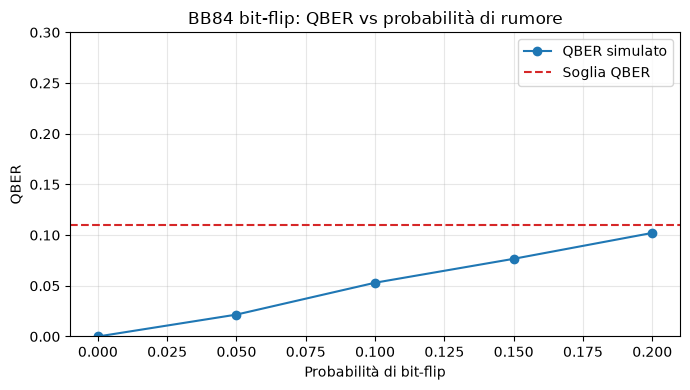

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_bit_flip_qber_vs_noise.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bb84_bit_flip_df["noise_probability"], bb84_bit_flip_df["qber"], marker="o", label="QBER simulato")
ax.axhline(QBER_THRESHOLD, linestyle="--", color="tab:red", label="Soglia QBER")
ax.set_title("BB84 bit-flip: QBER vs probabilità di rumore")
ax.set_xlabel("Probabilità di bit-flip")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.3, bb84_bit_flip_df["qber"].max() + 0.05))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "bb84_bit_flip_qber_vs_noise.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

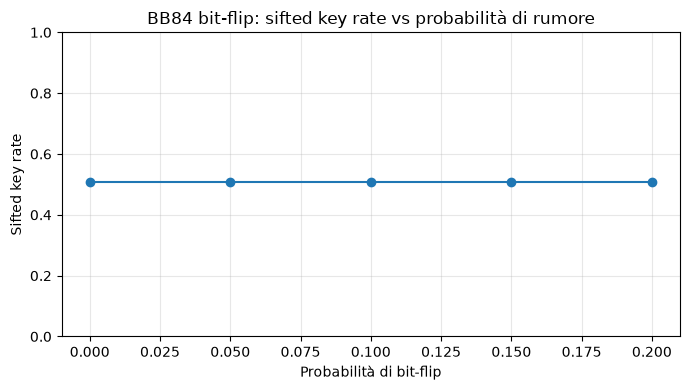

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_bit_flip_key_rate_vs_noise.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bb84_bit_flip_df["noise_probability"], bb84_bit_flip_df["sifted_key_rate"], marker="o")
ax.set_title("BB84 bit-flip: sifted key rate vs probabilità di rumore")
ax.set_xlabel("Probabilità di bit-flip")
ax.set_ylabel("Sifted key rate")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
fig.tight_layout()
figure_path = figures_dir / "bb84_bit_flip_key_rate_vs_noise.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## BB84 con amplitude damping

In [7]:
bb84_damping_rows = []

for i in range(len(DAMPING_PROBABILITIES)):
    gamma = DAMPING_PROBABILITIES[i]
    results = run_bb84_protocol_with_amplitude_damping(
        N_ROUNDS,
        damping_probability=gamma,
        seed=SEED,
    )
    metrics = compute_notebook_metrics(results)

    bb84_damping_rows.append({
        "protocol": "BB84",
        "noise_model": "amplitude_damping",
        "damping_probability": gamma,
        "n_rounds": N_ROUNDS,
        "sifted_key_length": metrics["sifted_key_length"],
        "sifted_key_rate": metrics["sifted_key_rate"],
        "qber": metrics["qber"],
        "qber_threshold": QBER_THRESHOLD,
        "accepted": decide_qber_acceptance(metrics["qber"], QBER_THRESHOLD),
        "seed": SEED,
    })

bb84_damping_df = pd.DataFrame(bb84_damping_rows)
bb84_damping_path = tables_dir / "bb84_amplitude_damping_sweep.csv"
bb84_damping_df.to_csv(bb84_damping_path, index=False)
print(f"Tabella salvata in: {bb84_damping_path}")
bb84_damping_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_amplitude_damping_sweep.csv


,protocol,noise_model,damping_probability,n_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,seed
0,BB84,amplitude_damping,0.00,1000,509,0.509,0.000000,0.11,True,42
1,BB84,amplitude_damping,0.05,1000,509,0.509,0.015717,0.11,True,42
2,BB84,amplitude_damping,0.10,1000,509,0.509,0.035363,0.11,True,42
3,BB84,amplitude_damping,0.15,1000,509,0.509,0.060904,0.11,True,42
4,BB84,amplitude_damping,0.20,1000,509,0.509,0.090373,0.11,True,42


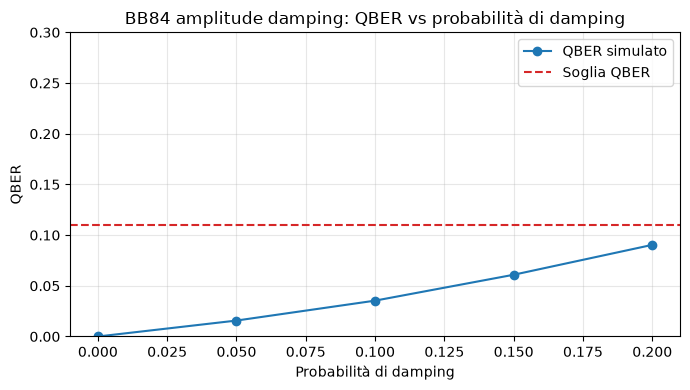

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_amplitude_damping_qber_vs_probability.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bb84_damping_df["damping_probability"], bb84_damping_df["qber"], marker="o", label="QBER simulato")
ax.axhline(QBER_THRESHOLD, linestyle="--", color="tab:red", label="Soglia QBER")
ax.set_title("BB84 amplitude damping: QBER vs probabilità di damping")
ax.set_xlabel("Probabilità di damping")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.3, bb84_damping_df["qber"].max() + 0.05))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "bb84_amplitude_damping_qber_vs_probability.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

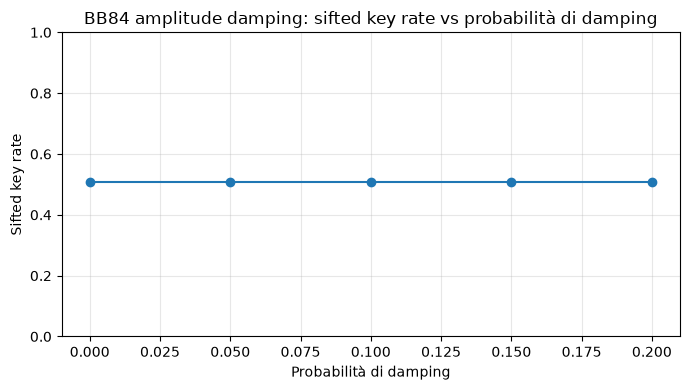

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_amplitude_damping_key_rate_vs_probability.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bb84_damping_df["damping_probability"], bb84_damping_df["sifted_key_rate"], marker="o")
ax.set_title("BB84 amplitude damping: sifted key rate vs probabilità di damping")
ax.set_xlabel("Probabilità di damping")
ax.set_ylabel("Sifted key rate")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
fig.tight_layout()
figure_path = figures_dir / "bb84_amplitude_damping_key_rate_vs_probability.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## BB84 con modello Jaynes-Cummings e distanza

In [10]:
bb84_jc_rows = []

for i in range(len(DISTANCES_KM)):
    distance_km = DISTANCES_KM[i]
    damping_probability = compute_jc_damping_probability_from_distance(distance_km)
    results = run_bb84_protocol_with_jc_amplitude_damping(
        N_ROUNDS,
        distance_km=distance_km,
        seed=SEED,
    )
    metrics = compute_notebook_metrics(results)

    bb84_jc_rows.append({
        "protocol": "BB84",
        "noise_model": "jc_amplitude_damping",
        "distance_km": distance_km,
        "damping_probability": damping_probability,
        "n_rounds": N_ROUNDS,
        "sifted_key_length": metrics["sifted_key_length"],
        "sifted_key_rate": metrics["sifted_key_rate"],
        "qber": metrics["qber"],
        "qber_threshold": QBER_THRESHOLD,
        "accepted": decide_qber_acceptance(metrics["qber"], QBER_THRESHOLD),
        "seed": SEED,
    })

bb84_jc_df = pd.DataFrame(bb84_jc_rows)
bb84_jc_path = tables_dir / "bb84_jc_qber_vs_distance.csv"
bb84_jc_df.to_csv(bb84_jc_path, index=False)
print(f"Tabella salvata in: {bb84_jc_path}")
bb84_jc_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_jc_qber_vs_distance.csv


,protocol,noise_model,distance_km,damping_probability,n_rounds,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,seed
0,BB84,jc_amplitude_damping,0,0.000000,1000,509,0.509,0.000000,0.11,True,42
1,BB84,jc_amplitude_damping,10,0.009979,1000,509,0.509,0.000000,0.11,True,42
2,BB84,jc_amplitude_damping,25,0.049821,1000,509,0.509,0.015717,0.11,True,42
3,BB84,jc_amplitude_damping,50,0.142236,1000,509,0.509,0.058939,0.11,True,42
4,BB84,jc_amplitude_damping,75,0.238556,1000,509,0.509,0.102161,0.11,True,42
5,BB84,jc_amplitude_damping,100,0.327856,1000,509,0.509,0.139489,0.11,False,42


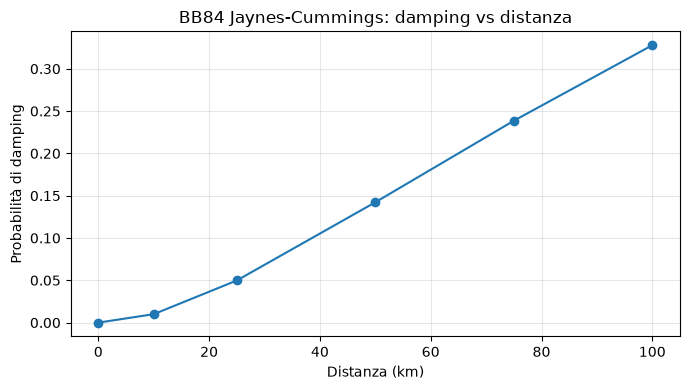

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_jc_damping_probability_vs_distance.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bb84_jc_df["distance_km"], bb84_jc_df["damping_probability"], marker="o")
ax.set_title("BB84 Jaynes-Cummings: damping vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("Probabilità di damping")
ax.grid(True, alpha=0.3)
fig.tight_layout()
figure_path = figures_dir / "bb84_jc_damping_probability_vs_distance.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

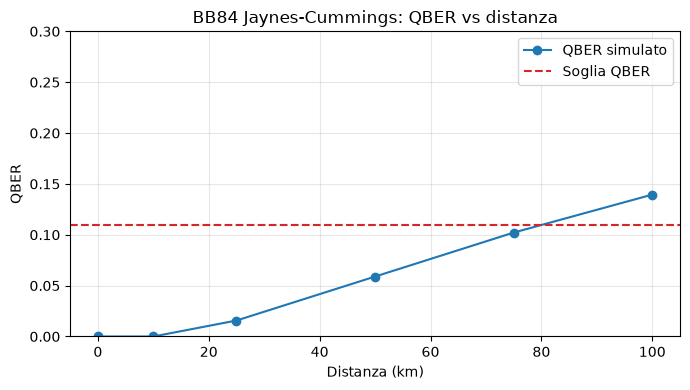

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_jc_qber_vs_distance.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bb84_jc_df["distance_km"], bb84_jc_df["qber"], marker="o", label="QBER simulato")
ax.axhline(QBER_THRESHOLD, linestyle="--", color="tab:red", label="Soglia QBER")
ax.set_title("BB84 Jaynes-Cummings: QBER vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.3, bb84_jc_df["qber"].max() + 0.05))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "bb84_jc_qber_vs_distance.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

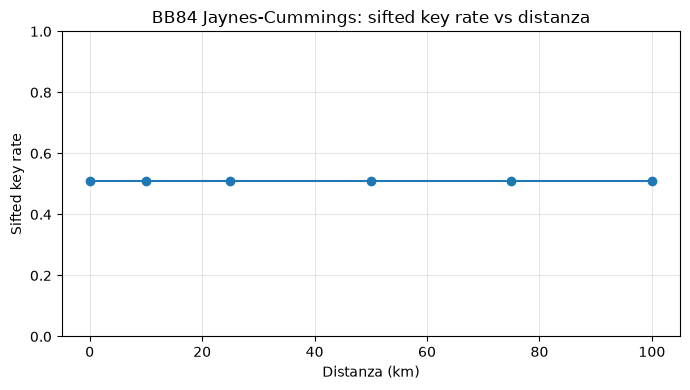

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_jc_key_rate_vs_distance.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bb84_jc_df["distance_km"], bb84_jc_df["sifted_key_rate"], marker="o")
ax.set_title("BB84 Jaynes-Cummings: sifted key rate vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("Sifted key rate")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
fig.tight_layout()
figure_path = figures_dir / "bb84_jc_key_rate_vs_distance.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## E91 con rumore bit-flip

In [14]:
e91_bit_flip_rows = []

for i in range(len(NOISE_PROBABILITIES)):
    probability = NOISE_PROBABILITIES[i]
    results = run_e91_protocol_with_bit_flip_noise(
        N_ROUNDS,
        noise_probability=probability,
        channel_mode=CHANNEL_MODE,
        seed=SEED,
    )
    metrics = compute_notebook_metrics(results)
    chsh_result = run_chsh_experiment_with_bit_flip_noise(
        noise_probability=probability,
        channel_mode=CHANNEL_MODE,
        shots=SHOTS_CHSH,
        seed=SEED,
    )

    e91_bit_flip_rows.append({
        "protocol": "E91",
        "noise_model": "bit_flip",
        "noise_probability": probability,
        "channel_mode": CHANNEL_MODE,
        "n_rounds": N_ROUNDS,
        "shots_chsh": SHOTS_CHSH,
        "sifted_key_length": metrics["sifted_key_length"],
        "sifted_key_rate": metrics["sifted_key_rate"],
        "qber": metrics["qber"],
        "qber_threshold": QBER_THRESHOLD,
        "accepted": decide_qber_acceptance(metrics["qber"], QBER_THRESHOLD),
        "S": chsh_result["S"],
        "abs_S": abs(chsh_result["S"]),
        "violates_chsh": abs(chsh_result["S"]) > CHSH_CLASSICAL_LIMIT,
        "seed": SEED,
    })

e91_bit_flip_df = pd.DataFrame(e91_bit_flip_rows)
e91_bit_flip_path = tables_dir / "e91_bit_flip_noise_sweep.csv"
e91_bit_flip_df.to_csv(e91_bit_flip_path, index=False)
print(f"Tabella salvata in: {e91_bit_flip_path}")
e91_bit_flip_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_bit_flip_noise_sweep.csv


,protocol,noise_model,noise_probability,channel_mode,n_rounds,shots_chsh,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,S,abs_S,violates_chsh,seed
0,E91,bit_flip,0.00,two_arm,1000,2000,489,0.489,0.000000,0.11,True,2.826,2.826,True,42
1,E91,bit_flip,0.05,two_arm,1000,2000,489,0.489,0.051125,0.11,True,2.559,2.559,True,42
2,E91,bit_flip,0.10,two_arm,1000,2000,489,0.489,0.094070,0.11,True,2.347,2.347,True,42
3,E91,bit_flip,0.15,two_arm,1000,2000,489,0.489,0.134969,0.11,False,2.118,2.118,True,42
4,E91,bit_flip,0.20,two_arm,1000,2000,489,0.489,0.163599,0.11,False,1.920,1.920,False,42


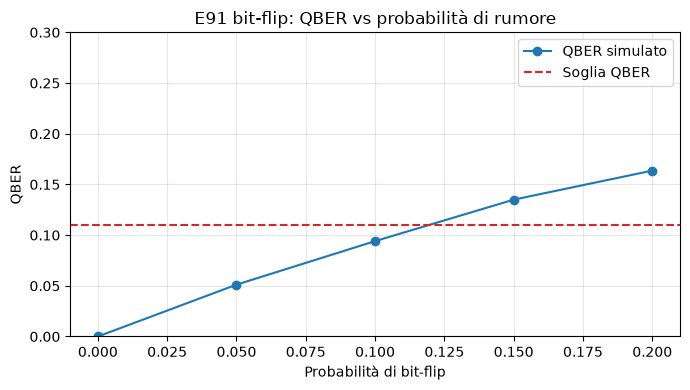

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_bit_flip_qber_vs_noise.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e91_bit_flip_df["noise_probability"], e91_bit_flip_df["qber"], marker="o", label="QBER simulato")
ax.axhline(QBER_THRESHOLD, linestyle="--", color="tab:red", label="Soglia QBER")
ax.set_title("E91 bit-flip: QBER vs probabilità di rumore")
ax.set_xlabel("Probabilità di bit-flip")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.3, e91_bit_flip_df["qber"].max() + 0.05))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "e91_bit_flip_qber_vs_noise.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

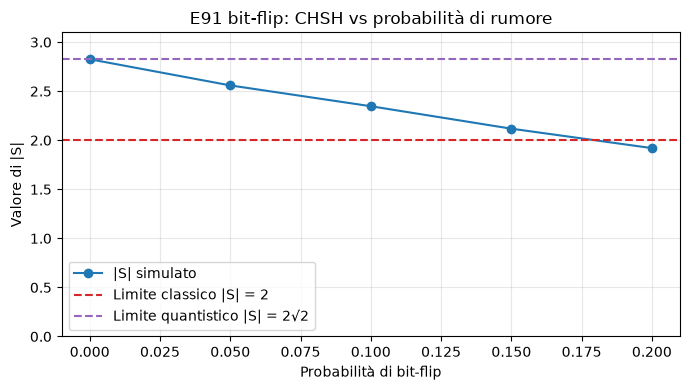

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_bit_flip_chsh_vs_noise.png


In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e91_bit_flip_df["noise_probability"], e91_bit_flip_df["abs_S"], marker="o", label="|S| simulato")
ax.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", color="tab:red", label="Limite classico |S| = 2")
ax.axhline(CHSH_TSIRELSON_BOUND, linestyle="--", color="tab:purple", label="Limite quantistico |S| = 2\u221a2")
ax.set_title("E91 bit-flip: CHSH vs probabilità di rumore")
ax.set_xlabel("Probabilità di bit-flip")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "e91_bit_flip_chsh_vs_noise.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## E91 con amplitude damping

In [17]:
e91_damping_rows = []

for i in range(len(DAMPING_PROBABILITIES)):
    gamma = DAMPING_PROBABILITIES[i]
    results = run_e91_protocol_with_amplitude_damping(
        N_ROUNDS,
        damping_probability=gamma,
        channel_mode=CHANNEL_MODE,
        seed=SEED,
    )
    metrics = compute_notebook_metrics(results)
    chsh_result = run_chsh_experiment_with_amplitude_damping(
        damping_probability=gamma,
        channel_mode=CHANNEL_MODE,
        shots=SHOTS_CHSH,
        seed=SEED,
    )

    e91_damping_rows.append({
        "protocol": "E91",
        "noise_model": "amplitude_damping",
        "damping_probability": gamma,
        "channel_mode": CHANNEL_MODE,
        "n_rounds": N_ROUNDS,
        "shots_chsh": SHOTS_CHSH,
        "sifted_key_length": metrics["sifted_key_length"],
        "sifted_key_rate": metrics["sifted_key_rate"],
        "qber": metrics["qber"],
        "qber_threshold": QBER_THRESHOLD,
        "accepted": decide_qber_acceptance(metrics["qber"], QBER_THRESHOLD),
        "S": chsh_result["S"],
        "abs_S": abs(chsh_result["S"]),
        "violates_chsh": abs(chsh_result["S"]) > CHSH_CLASSICAL_LIMIT,
        "seed": SEED,
    })

e91_damping_df = pd.DataFrame(e91_damping_rows)
e91_damping_path = tables_dir / "e91_amplitude_damping_sweep.csv"
e91_damping_df.to_csv(e91_damping_path, index=False)
print(f"Tabella salvata in: {e91_damping_path}")
e91_damping_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_amplitude_damping_sweep.csv


,protocol,noise_model,damping_probability,channel_mode,n_rounds,shots_chsh,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,S,abs_S,violates_chsh,seed
0,E91,amplitude_damping,0.00,two_arm,1000,2000,489,0.489,0.000000,0.11,True,2.830,2.830,True,42
1,E91,amplitude_damping,0.05,two_arm,1000,2000,489,0.489,0.044990,0.11,True,2.642,2.642,True,42
2,E91,amplitude_damping,0.10,two_arm,1000,2000,489,0.489,0.073620,0.11,True,2.444,2.444,True,42
3,E91,amplitude_damping,0.15,two_arm,1000,2000,489,0.489,0.096115,0.11,True,2.287,2.287,True,42
4,E91,amplitude_damping,0.20,two_arm,1000,2000,489,0.489,0.114519,0.11,False,2.131,2.131,True,42


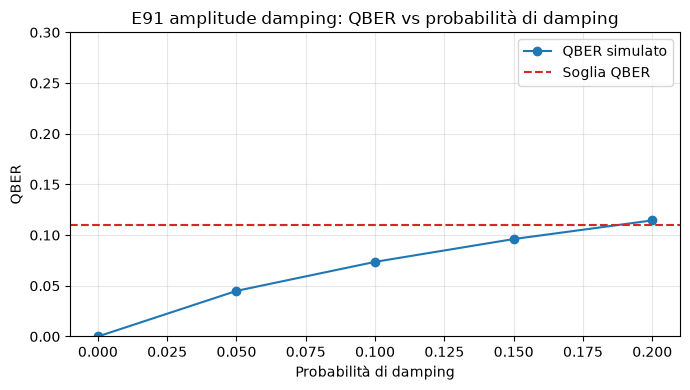

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_amplitude_damping_qber_vs_probability.png


In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e91_damping_df["damping_probability"], e91_damping_df["qber"], marker="o", label="QBER simulato")
ax.axhline(QBER_THRESHOLD, linestyle="--", color="tab:red", label="Soglia QBER")
ax.set_title("E91 amplitude damping: QBER vs probabilità di damping")
ax.set_xlabel("Probabilità di damping")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.3, e91_damping_df["qber"].max() + 0.05))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "e91_amplitude_damping_qber_vs_probability.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

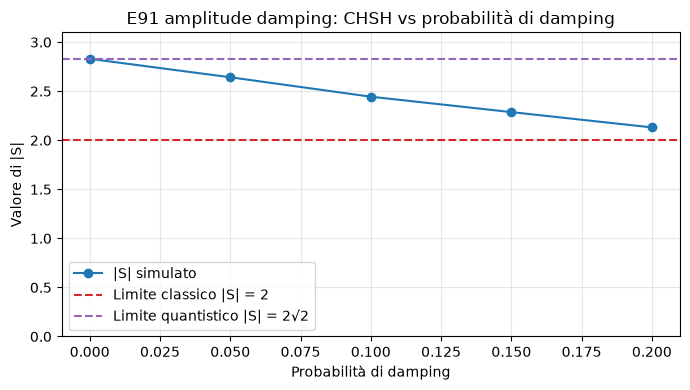

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_amplitude_damping_chsh_vs_probability.png


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e91_damping_df["damping_probability"], e91_damping_df["abs_S"], marker="o", label="|S| simulato")
ax.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", color="tab:red", label="Limite classico |S| = 2")
ax.axhline(CHSH_TSIRELSON_BOUND, linestyle="--", color="tab:purple", label="Limite quantistico |S| = 2\u221a2")
ax.set_title("E91 amplitude damping: CHSH vs probabilità di damping")
ax.set_xlabel("Probabilità di damping")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "e91_amplitude_damping_chsh_vs_probability.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## E91 con modello Jaynes-Cummings e distanza

In [20]:
e91_jc_rows = []

for i in range(len(DISTANCES_KM)):
    distance_km = DISTANCES_KM[i]
    results = run_e91_protocol_with_jc_amplitude_damping(
        N_ROUNDS,
        distance_km=distance_km,
        channel_mode=CHANNEL_MODE,
        seed=SEED,
    )
    metrics = compute_notebook_metrics(results)
    chsh_result = run_chsh_experiment_with_jc_amplitude_damping(
        distance_km=distance_km,
        channel_mode=CHANNEL_MODE,
        shots=SHOTS_CHSH,
        seed=SEED,
    )

    e91_jc_rows.append({
        "protocol": "E91",
        "noise_model": "jc_amplitude_damping",
        "distance_km": distance_km,
        "damping_probability": chsh_result["damping_probability_bob"],
        "channel_mode": CHANNEL_MODE,
        "n_rounds": N_ROUNDS,
        "shots_chsh": SHOTS_CHSH,
        "sifted_key_length": metrics["sifted_key_length"],
        "sifted_key_rate": metrics["sifted_key_rate"],
        "qber": metrics["qber"],
        "qber_threshold": QBER_THRESHOLD,
        "accepted": decide_qber_acceptance(metrics["qber"], QBER_THRESHOLD),
        "S": chsh_result["S"],
        "abs_S": abs(chsh_result["S"]),
        "violates_chsh": abs(chsh_result["S"]) > CHSH_CLASSICAL_LIMIT,
        "seed": SEED,
    })

e91_jc_df = pd.DataFrame(e91_jc_rows)
e91_jc_path = tables_dir / "e91_jc_distance_sweep.csv"
e91_jc_df.to_csv(e91_jc_path, index=False)
print(f"Tabella salvata in: {e91_jc_path}")
e91_jc_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\e91_jc_distance_sweep.csv


,protocol,noise_model,distance_km,damping_probability,channel_mode,n_rounds,shots_chsh,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,S,abs_S,violates_chsh,seed
0,E91,jc_amplitude_damping,0,0.000000,two_arm,1000,2000,489,0.489,0.000000,0.11,True,2.830,2.830,True,42
1,E91,jc_amplitude_damping,10,0.002698,two_arm,1000,2000,489,0.489,0.000000,0.11,True,2.821,2.821,True,42
2,E91,jc_amplitude_damping,25,0.015003,two_arm,1000,2000,489,0.489,0.006135,0.11,True,2.777,2.777,True,42
3,E91,jc_amplitude_damping,50,0.049821,two_arm,1000,2000,489,0.489,0.028630,0.11,True,2.643,2.643,True,42
4,E91,jc_amplitude_damping,75,0.094157,two_arm,1000,2000,489,0.489,0.051125,0.11,True,2.464,2.464,True,42
5,E91,jc_amplitude_damping,100,0.142236,two_arm,1000,2000,489,0.489,0.085890,0.11,True,2.314,2.314,True,42


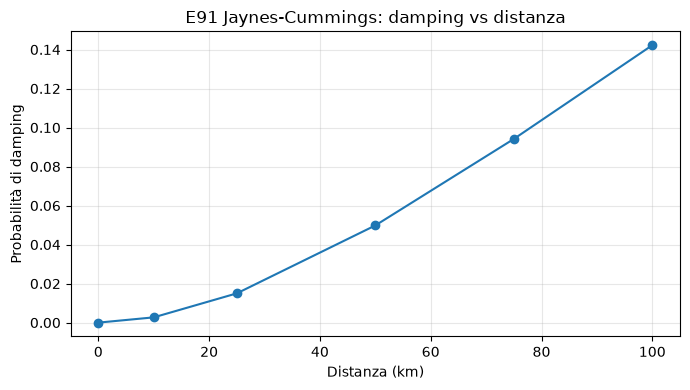

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_jc_damping_probability_vs_distance.png


In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e91_jc_df["distance_km"], e91_jc_df["damping_probability"], marker="o")
ax.set_title("E91 Jaynes-Cummings: damping vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("Probabilità di damping")
ax.grid(True, alpha=0.3)
fig.tight_layout()
figure_path = figures_dir / "e91_jc_damping_probability_vs_distance.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

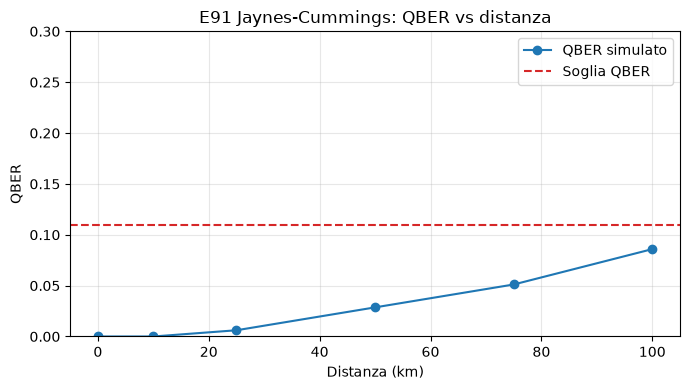

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_jc_qber_vs_distance.png


In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e91_jc_df["distance_km"], e91_jc_df["qber"], marker="o", label="QBER simulato")
ax.axhline(QBER_THRESHOLD, linestyle="--", color="tab:red", label="Soglia QBER")
ax.set_title("E91 Jaynes-Cummings: QBER vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.3, e91_jc_df["qber"].max() + 0.05))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "e91_jc_qber_vs_distance.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

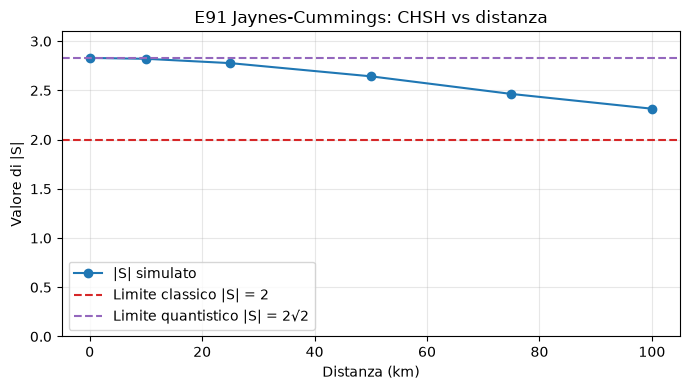

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\e91_jc_chsh_vs_distance.png


In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(e91_jc_df["distance_km"], e91_jc_df["abs_S"], marker="o", label="|S| simulato")
ax.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", color="tab:red", label="Limite classico |S| = 2")
ax.axhline(CHSH_TSIRELSON_BOUND, linestyle="--", color="tab:purple", label="Limite quantistico |S| = 2\u221a2")
ax.set_title("E91 Jaynes-Cummings: CHSH vs distanza")
ax.set_xlabel("Distanza (km)")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "e91_jc_chsh_vs_distance.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## Sintesi rappresentativa

In [24]:
representative_rows = []

bb84_bit_flip_row = bb84_bit_flip_df[bb84_bit_flip_df["noise_probability"] == 0.10].iloc[0]
bb84_damping_row = bb84_damping_df[bb84_damping_df["damping_probability"] == 0.10].iloc[0]
bb84_jc_row = bb84_jc_df[bb84_jc_df["distance_km"] == 50].iloc[0]
e91_bit_flip_row = e91_bit_flip_df[e91_bit_flip_df["noise_probability"] == 0.10].iloc[0]
e91_damping_row = e91_damping_df[e91_damping_df["damping_probability"] == 0.10].iloc[0]
e91_jc_row = e91_jc_df[e91_jc_df["distance_km"] == 50].iloc[0]

representative_rows.append({"protocol": "BB84", "noise_model": "bit_flip", "parameter": "p = 0.10", "qber": bb84_bit_flip_row["qber"], "sifted_key_rate": bb84_bit_flip_row["sifted_key_rate"], "accepted": bb84_bit_flip_row["accepted"], "abs_S": None, "violates_chsh": None})
representative_rows.append({"protocol": "BB84", "noise_model": "amplitude_damping", "parameter": "gamma = 0.10", "qber": bb84_damping_row["qber"], "sifted_key_rate": bb84_damping_row["sifted_key_rate"], "accepted": bb84_damping_row["accepted"], "abs_S": None, "violates_chsh": None})
representative_rows.append({"protocol": "BB84", "noise_model": "jc_amplitude_damping", "parameter": "distance = 50 km", "qber": bb84_jc_row["qber"], "sifted_key_rate": bb84_jc_row["sifted_key_rate"], "accepted": bb84_jc_row["accepted"], "abs_S": None, "violates_chsh": None})
representative_rows.append({"protocol": "E91", "noise_model": "bit_flip", "parameter": "p = 0.10", "qber": e91_bit_flip_row["qber"], "sifted_key_rate": e91_bit_flip_row["sifted_key_rate"], "accepted": e91_bit_flip_row["accepted"], "abs_S": e91_bit_flip_row["abs_S"], "violates_chsh": e91_bit_flip_row["violates_chsh"]})
representative_rows.append({"protocol": "E91", "noise_model": "amplitude_damping", "parameter": "gamma = 0.10", "qber": e91_damping_row["qber"], "sifted_key_rate": e91_damping_row["sifted_key_rate"], "accepted": e91_damping_row["accepted"], "abs_S": e91_damping_row["abs_S"], "violates_chsh": e91_damping_row["violates_chsh"]})
representative_rows.append({"protocol": "E91", "noise_model": "jc_amplitude_damping", "parameter": "distance = 50 km", "qber": e91_jc_row["qber"], "sifted_key_rate": e91_jc_row["sifted_key_rate"], "accepted": e91_jc_row["accepted"], "abs_S": e91_jc_row["abs_S"], "violates_chsh": e91_jc_row["violates_chsh"]})

representative_df = pd.DataFrame(representative_rows)
representative_path = tables_dir / "noise_representative_summary.csv"
representative_df.to_csv(representative_path, index=False)
print(f"Tabella salvata in: {representative_path}")
representative_df

Tabella salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\noise_representative_summary.csv


,protocol,noise_model,parameter,qber,sifted_key_rate,accepted,abs_S,violates_chsh
0,BB84,bit_flip,p = 0.10,0.053045,0.509,True,NaN,None
1,BB84,amplitude_damping,gamma = 0.10,0.035363,0.509,True,NaN,None
2,BB84,jc_amplitude_damping,distance = 50 km,0.058939,0.509,True,NaN,None
3,E91,bit_flip,p = 0.10,0.094070,0.489,True,2.347,True
4,E91,amplitude_damping,gamma = 0.10,0.073620,0.489,True,2.444,True
5,E91,jc_amplitude_damping,distance = 50 km,0.028630,0.489,True,2.643,True


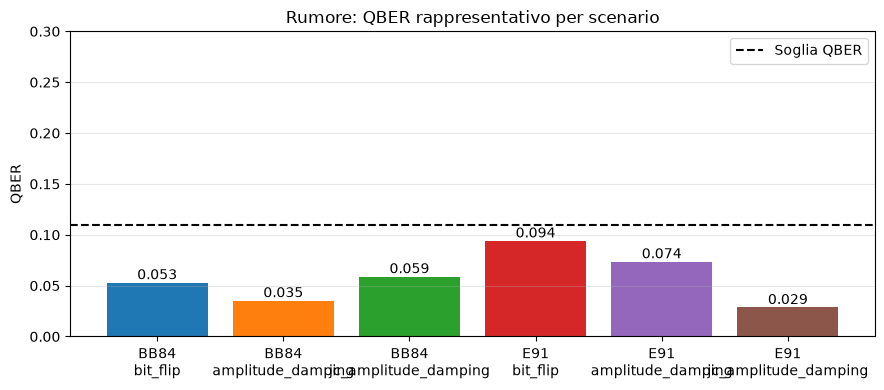

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\noise_representative_qber.png


In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = []
for i in range(len(representative_df)):
    labels.append(representative_df.iloc[i]["protocol"] + "\n" + representative_df.iloc[i]["noise_model"])
values = representative_df["qber"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]
bars = ax.bar(labels, values, color=colors)
ax.axhline(QBER_THRESHOLD, linestyle="--", color="black", label="Soglia QBER")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom")
ax.set_title("Rumore: QBER rappresentativo per scenario")
ax.set_ylabel("QBER")
ax.set_ylim(0, max(0.3, representative_df["qber"].max() + 0.05))
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
figure_path = figures_dir / "noise_representative_qber.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

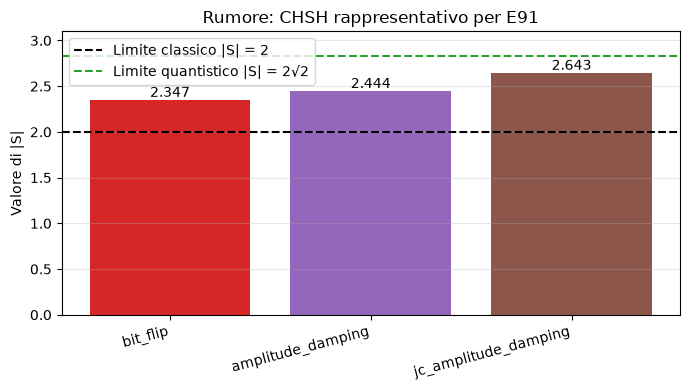

Grafico salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\noise_representative_chsh.png


In [26]:
e91_representative_df = representative_df[representative_df["protocol"] == "E91"]
fig, ax = plt.subplots(figsize=(7, 4))
labels = []
for i in range(len(e91_representative_df)):
    labels.append(e91_representative_df.iloc[i]["noise_model"])
values = e91_representative_df["abs_S"]
colors = ["tab:red", "tab:purple", "tab:brown"]
bars = ax.bar(labels, values, color=colors)
ax.axhline(CHSH_CLASSICAL_LIMIT, linestyle="--", color="black", label="Limite classico |S| = 2")
ax.axhline(CHSH_TSIRELSON_BOUND, linestyle="--", color="tab:green", label="Limite quantistico |S| = 2\u221a2")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom")
ax.set_title("Rumore: CHSH rappresentativo per E91")
ax.set_ylabel("Valore di |S|")
ax.set_ylim(0, 3.1)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.xticks(rotation=15, ha="right")
fig.tight_layout()
figure_path = figures_dir / "noise_representative_chsh.png"
fig.savefig(figure_path, dpi=300)
plt.show()
print(f"Grafico salvato in: {figure_path}")

## Commento finale

Bit-flip e amplitude damping rappresentano due modelli di rumore diversi: il primo introduce errori discreti sul bit, mentre il secondo descrive un effetto dissipativo.

Il modello Jaynes-Cummings collega rumore e distanza nel canale. In BB84 l'impatto si legge soprattutto sul QBER; in E91 il rumore degrada sia QBER sia violazione CHSH.

Questa parte è collegata all'articolo sulla dissipative dynamics in BB84 QKD e prepara il confronto finale tra protocolli ideali, attacchi e canali rumorosi.